In [139]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')

import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools
ext = 'pdf'

[{'oells': (0, 2, 4)}]


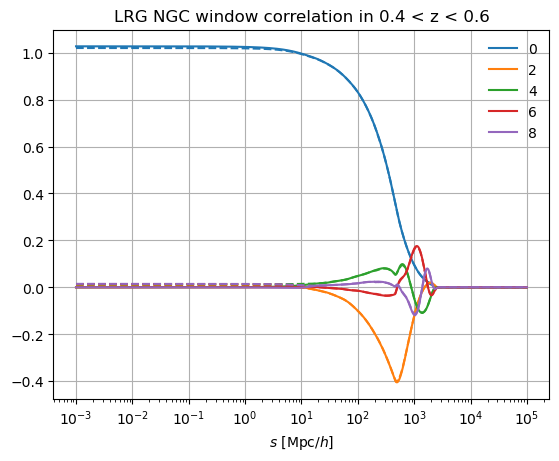

In [66]:
stats_dir = tools.base_stats_dir

for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO'][:1]:
    for zrange in tools.propose_fiducial('zranges', tracer)[:1]:
        for kind in ['mesh2_spectrum']:
            npt = 2 if '2' in kind else 3
            method = 'smooth_mesh'
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind.replace("_spectrum", "")}_correlation_raw',
                                    version='abacus-hf-dr2-v2-altmtl', tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                                    basis='sugiyama-diagonal', imock=0, battrs={'s': None, 'pole': None}, extra='complete')
            window_correlation_mesh = types.read(fn)
        
            method = 'smooth_particle'
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/cutsky_window_function_validation', kind=f'window_{method}{npt:d}_correlation_raw',
                                    version='abacus-hf-dr2-v2-altmtl', tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                                    basis='sugiyama-diagonal', extra=f'complete_{method}', imock=0, battrs={'s': None, 'pole': None})
            window_correlation_particle = types.read(fn)
            
            fig, ax = plt.subplots()
            ax.set_title(f'{tracer} {region} window correlation in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            ells = [label['ells'] for label in window_correlation_mesh.labels(level=None)]
            print(window_correlation_particle.labels(level=None))
            for ill, ell in enumerate(ells):
                color = f'C{ill:d}'
                pole_mesh = window_correlation_mesh.get(ells=ell)
                pole_particle = window_correlation_particle.get(ells=ell)
                ax.plot(s:=pole_mesh.coords('s'), pole_mesh.value(), color=color, linestyle='-', label=ell)
                ax.plot(s:=pole_particle.coords('s'), pole_particle.value(), color=color, linestyle='--')
            ax.legend(frameon=False)
            ax.set_xscale('log')
            ax.set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
            ax.grid(True)
            plt.show()

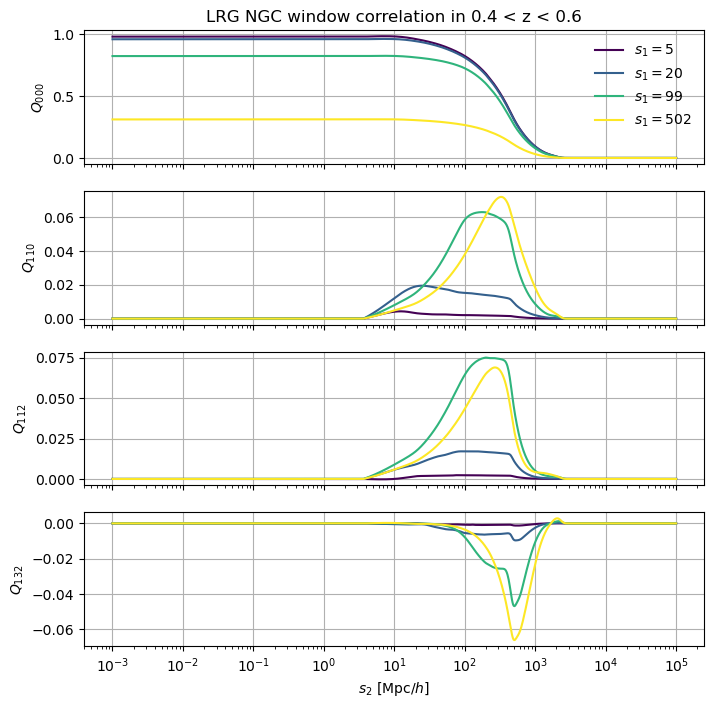

/tmp/ipykernel_1629671/2672337109.py:53: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(s:=pole.coords('s1'), pole.value().diagonal(), color=color, linestyle='-', label=ell)


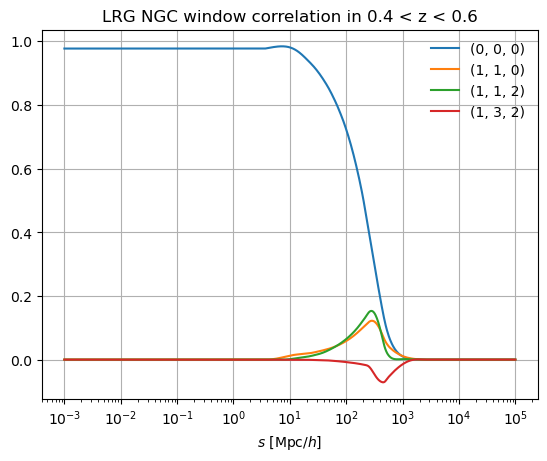

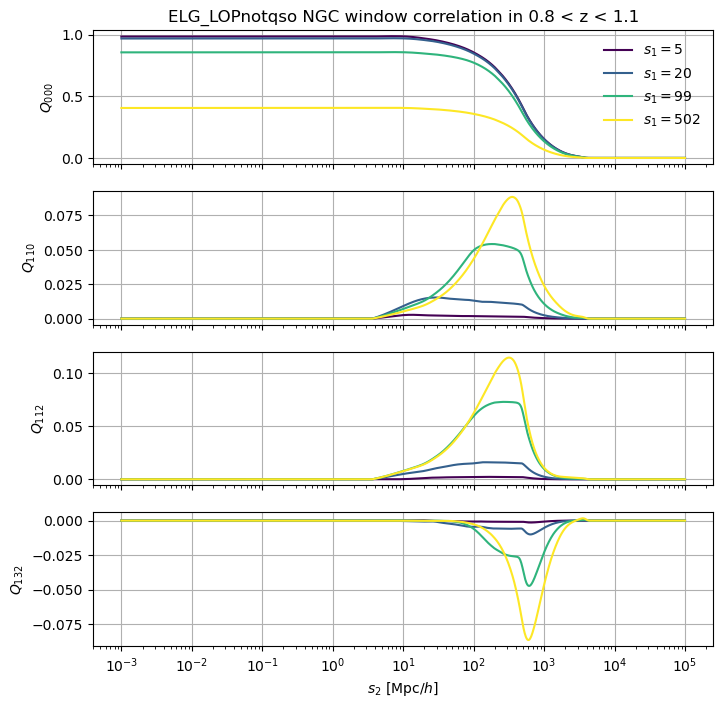

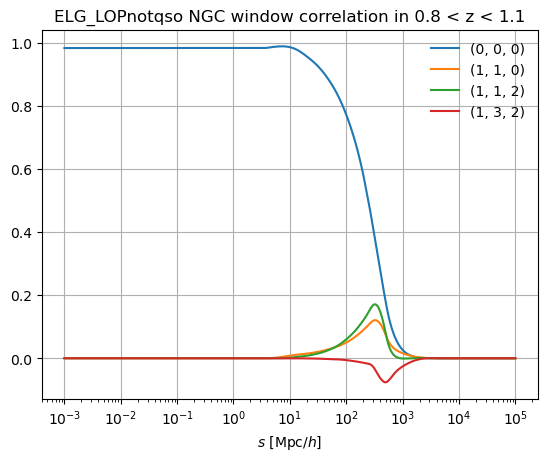

In [142]:
stats_dir = tools.base_stats_dir

for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO'][:2]:
    for zrange in tools.propose_fiducial('zranges', tracer)[:1]:
        for kind in ['mesh3_spectrum']:
            npt = 2 if '2' in kind else 3
            method = 'smooth_mesh'
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind.replace("_spectrum", "")}_correlation_raw',
                                    version='abacus-hf-dr2-v2-altmtl', tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                                    basis='sugiyama-diagonal', imock=0, battrs={'s': None, 'pole': None}, extra='complete')
            window_correlation_mesh = types.read(fn)
        
            method = 'smooth_particle'
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/cutsky_window_function_validation', kind=f'window_{method}{npt:d}_correlation_raw',
                                    version='abacus-hf-dr2-v2-altmtl', tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                                    basis='sugiyama-diagonal', extra=f'complete_{method}', imock=0, battrs={'s': None, 'pole': None})
        
            window_correlation_particle = types.read(fn)
            #window_correlation_particle = window_correlation_particle.select(s1=(10., 1e6), s2=(10., 1e6))

            ells = [(0, 0, 0), (1, 1, 0), (1, 1, 2), (1, 3, 2)]
            logs1 = np.log10([5., 20., 100., 500.])
            fig, lax = plt.subplots(len(ells), figsize=(8, 8), sharex=True, squeeze=False)
            lax = lax.ravel()
            
            # Colormap for s1
            cmap = plt.get_cmap('viridis')
            norm = mpl.colors.Normalize(vmin=min(logs1), vmax=max(logs1))

            for ill, ell in enumerate(ells):
                label = {'ells': ell}
                pole = window_correlation_particle.get(**label)
                ax = lax[ill]
                for s1 in logs1:
                    s1 = 10**s1
                    is1 = np.argmin(np.abs(pole.coords('s1') - s1))
                    s1 = pole.coords('s1')[is1]
                    color = cmap(norm(np.log10(s1)))
                    ax.plot(s:=pole.coords('s2'), pole.value()[is1, :], color=color, linestyle='-', label=fr'$s_1 = {s1:.0f}$')
                ax.grid(True)
                ax.set_ylabel(rf'$Q_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}$')
            lax[0].set_title(f'{tracer} {region} window correlation in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            lax[0].legend(frameon=False)
            lax[-1].set_xscale('log')
            lax[-1].set_xlabel(r'$s_2$ [$\mathrm{Mpc}/h$]')
            plt.show()

            fig, ax = plt.subplots()
            for ill, ell in enumerate(ells):
                color = f'C{ill:d}'
                label = {'ells': ell}
                pole = window_correlation_particle.get(**label)
                ax.plot(s:=pole.coords('s1'), pole.value().diagonal(), color=color, linestyle='-', label=ell)
            ax.grid(True)
            ax.set_title(f'{tracer} {region} window correlation in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            ax.legend(frameon=False)
            ax.set_xscale('log')
            ax.set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
            plt.show()

In [ ]:
stats_dir = tools.base_stats_dir

for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO'][:2]:
    for zrange in tools.propose_fiducial('zranges', tracer)[:1]:
        for kind in ['mesh3_spectrum']:
            npt = 2 if '2' in kind else 3
            method = 'smooth_mesh'
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind.replace("_spectrum", "")}_correlation_raw',
                                    version='abacus-hf-dr2-v2-altmtl', tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                                    basis='sugiyama-diagonal', imock=0, battrs={'s': None, 'pole': None}, extra='complete')
            window_correlation_mesh = types.read(fn)
        
            method = 'smooth_particle'
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/cutsky_window_function_validation', kind=f'window_{method}{npt:d}_correlation_raw',
                                    version='abacus-hf-dr2-v2-altmtl', tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                                    basis='sugiyama-diagonal', extra=f'complete_{method}', imock=0, battrs={'s': None, 'pole': None})
        
            window_correlation_particle = types.read(fn)
            #window_correlation_particle = window_correlation_particle.select(s1=(10., 1e6), s2=(10., 1e6))

            ells = [(0, 0, 0), (1, 1, 0), (1, 1, 2), (1, 3, 2)]
            logs1 = np.log10([5., 20., 100., 500.])
            fig, lax = plt.subplots(len(ells), figsize=(8, 8), sharex=True, squeeze=False)
            lax = lax.ravel()
            
            # Colormap for s1
            cmap = plt.get_cmap('viridis')
            norm = mpl.colors.Normalize(vmin=min(logs1), vmax=max(logs1))

            for ill, ell in enumerate(ells):
                label = {'ells': ell}
                pole = window_correlation_particle.get(**label)
                ax = lax[ill]
                for s1 in logs1:
                    s1 = 10**s1
                    is1 = np.argmin(np.abs(pole.coords('s1') - s1))
                    s1 = pole.coords('s1')[is1]
                    color = cmap(norm(np.log10(s1)))
                    ax.plot(s:=pole.coords('s2'), pole.value()[is1, :], color=color, linestyle='-', label=fr'$s_1 = {s1:.0f}$')
                ax.grid(True)
                ax.set_ylabel(rf'$Q_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}$')
            lax[0].set_title(f'{tracer} {region} window correlation in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            lax[0].legend(frameon=False)
            lax[-1].set_xscale('log')
            lax[-1].set_xlabel(r'$s_2$ [$\mathrm{Mpc}/h$]')
            plt.show()

            fig, ax = plt.subplots()
            for ill, ell in enumerate(ells):
                color = f'C{ill:d}'
                label = {'ells': ell}
                pole = window_correlation_particle.get(**label)
                ax.plot(s:=pole.coords('s1'), pole.value().diagonal(), color=color, linestyle='-', label=ell)
            ax.grid(True)
            ax.set_title(f'{tracer} {region} window correlation in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            ax.legend(frameon=False)
            ax.set_xscale('log')
            ax.set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
            plt.show()

In [ ]:
stats_dir = tools.base_stats_dir

for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO'][:1]:
    for zrange in tools.propose_fiducial('zranges', tracer)[:1]:
        for kind in ['mesh3_spectrum']:
            npt = 2 if '2' in kind else 3
            method = 'smooth_mesh'
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind.replace("_spectrum", "")}_correlation_raw',
                                    version='abacus-hf-dr2-v2-altmtl', tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                                    basis='sugiyama-diagonal', imock=0, battrs={'s': None, 'pole': None}, extra='complete')
            window_correlation_mesh = types.read(fn)
        
            method = 'smooth_particle'
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/cutsky_window_function_validation', kind=f'window_{method}{npt:d}_correlation_raw',
                                    version='abacus-hf-dr2-v2-altmtl', tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                                    basis='sugiyama-diagonal', extra=f'complete_{method}', imock=0, battrs={'s': None, 'pole': None})
        
            window_correlation_particle = types.read(fn)
            #window_correlation_particle = window_correlation_particle.select(s1=(10., 1e6), s2=(10., 1e6))

            ells = [(0, 0, 0), (1, 1, 0), (0, 2, 2)]
            logs1 = np.log10([5., 20., 100., 500.])
            fig, lax = plt.subplots(len(ells), sharex=True, squeeze=False)
            lax = lax.ravel()
            
            # Colormap for s1
            cmap = plt.get_cmap('viridis')
            norm = mpl.colors.Normalize(vmin=min(logs1), vmax=max(logs1))

            for ill, ell in enumerate(ells):
                label = {'ells': ell}
                pole = window_correlation_particle.get(**label)
                ax = lax[ill]
                for s1 in logs1:
                    s1 = 10**s1
                    is1 = np.argmin(np.abs(pole.coords('s1') - s1))
                    s1 = pole.coords('s1')[is1]
                    color = cmap(norm(np.log10(s1)))
                    ax.plot(s:=pole.coords('s2'), pole.value()[is1, :], color=color, linestyle='-', label=fr'$s_1 = {s1:.0f}$')
                ax.grid(True)
                ax.set_ylabel(rf'$Q_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}$')
            lax[0].set_title(f'{tracer} {region} window correlation in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            lax[0].legend(frameon=False)
            lax[-1].set_xscale('log')
            lax[-1].set_xlabel(r'$s_2$ [$\mathrm{Mpc}/h$]')
            plt.show()

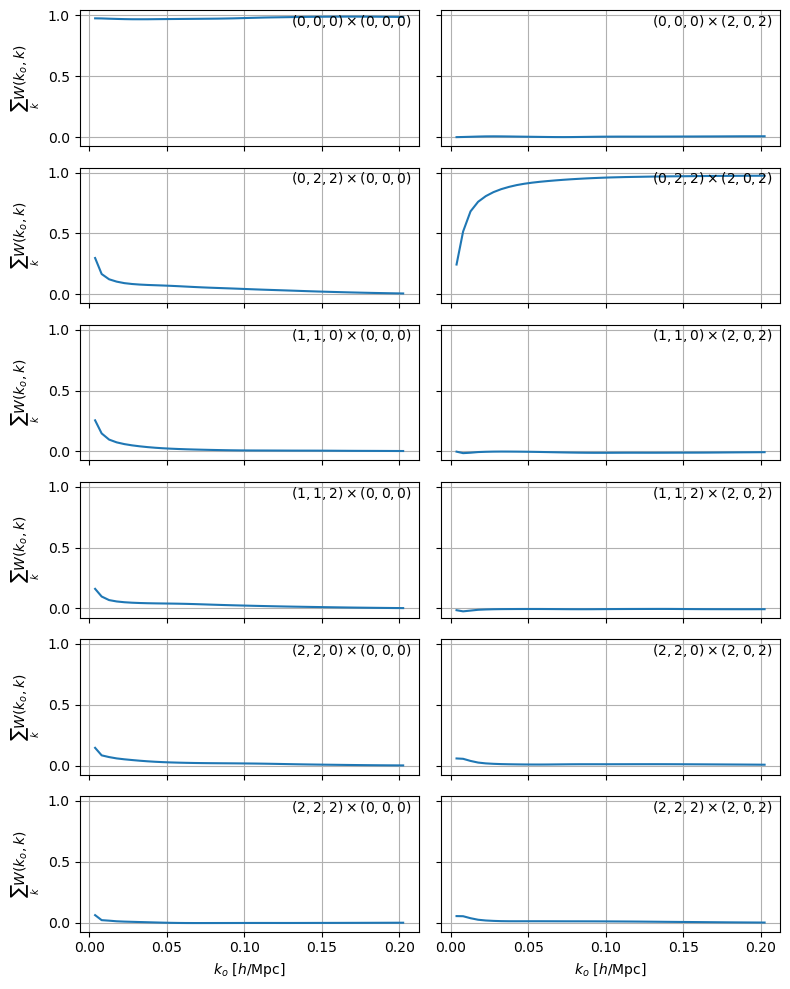

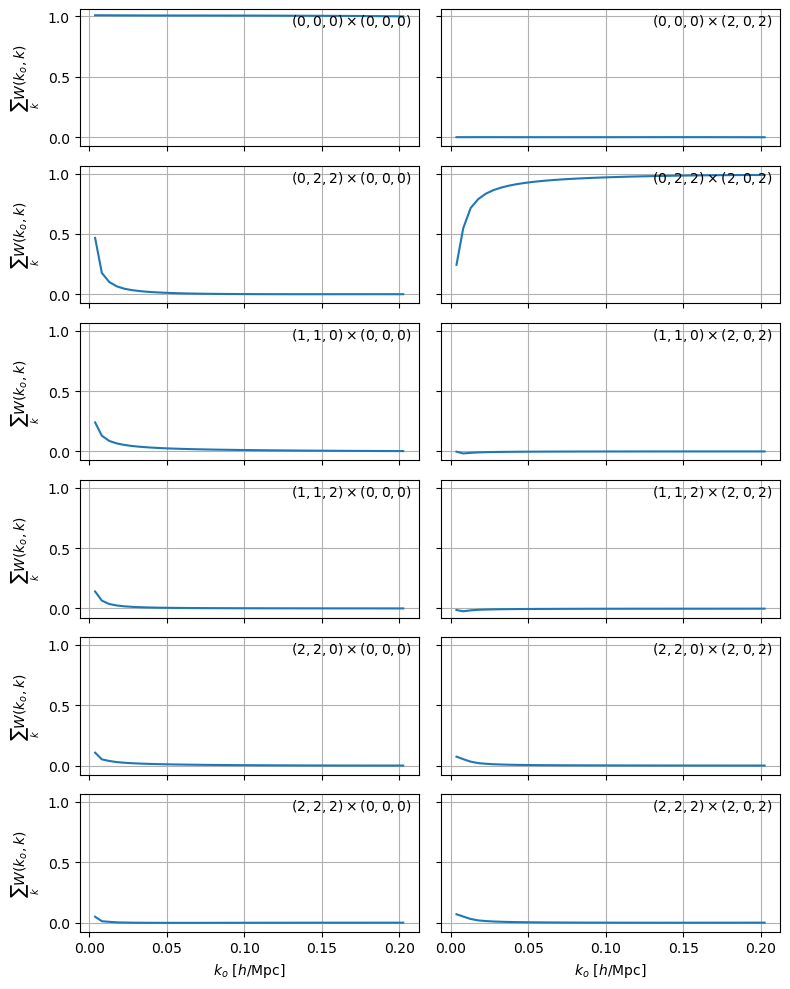

In [116]:
def plot_window_block_offsets(window, iko=20, offsets=np.arange(-2, 3), figsize=(10, 16), cmap='viridis'):
    theory, observable = window.theory, window.observable
    tlabels = theory.labels()
    olabels = observable.labels()
    fig, lax = plt.subplots(len(tlabels), len(olabels), figsize=figsize, squeeze=False, sharex=True, sharey=True)
    cmap = plt.get_cmap(cmap)
    norm = mpl.colors.Normalize(vmin=offsets.min(), vmax=offsets.max())

    for ti, tlabel in enumerate(tlabels):
        for oi, olabel in enumerate(olabels):
            block = window.at.theory.get(**tlabel).at.observable.get(**olabel)
            kt = block.theory.unravel().coords('k1')
            idx1 = np.arange(len(kt))
            ax = lax[ti, oi]

            for offset in offsets:
                idx2 = offset + idx1
                mask = (idx2 >= 0) & (idx2 < len(kt))
                index = np.ravel_multi_index((idx1[mask], idx2[mask]), dims=(len(kt), len(kt)))
                ax.plot(block.theory.coords('k')[index, 0], block.value()[iko, index], color=cmap(norm(offset)), label=fr'$\Delta i = {offset}$')

            ax.grid(True)
            ax.text(0.98, 0.98,
                rf"${tlabel['ells']}\times{olabel['ells']}$",
                transform=ax.transAxes,
                ha='right',
                va='top',
            )
            if ti == len(tlabels) - 1:
                ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
            if oi == 0:
                ax.set_ylabel(r'$W(k_o, k)$')

    ko = block.observable.coords('k')[iko, 0]
    fig.suptitle(rf'$k_o = {ko:.4f}\ h/\mathrm{{Mpc}}$', y=0.995)
    lax[0, 0].legend(frameon=False, ncol=len(offsets) // 2)
    fig.tight_layout()
    plt.show()
    return fig, lax


def plot_window_block_pcolormesh(window, iko=20, figsize=(6, 12), cmap='RdBu_r'):
    theory, observable = window.theory, window.observable
    tlabels = theory.labels()
    olabels = observable.labels()

    # First pass: collect blocks and common color scale
    blocks = {}
    vmin, vmax = np.inf, -np.inf

    for ti, tlabel in enumerate(tlabels):
        for oi, olabel in enumerate(olabels):
            block = window.at.theory.get(**tlabel).at.observable.get(**olabel)
            shape = tuple(len(coord) for coord in block.theory.unravel().coords().values())
            values = block.value()[iko].reshape(shape)

            blocks[ti, oi] = block, values
            vmin = min(vmin, np.nanmin(values))
            vmax = max(vmax, np.nanmax(values))

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    fig, lax = plt.subplots(len(tlabels), len(olabels), figsize=figsize, squeeze=False, sharex=True, sharey=True)

    for ti, tlabel in enumerate(tlabels):
        for oi, olabel in enumerate(olabels):
            ax = lax[ti, oi]
            block, values = blocks[ti, oi]
            mesh = ax.pcolormesh(*block.theory.unravel().coords().values(), values, cmap=cmap, norm=norm, shading='auto')
            ax.text(0.98, 0.98, rf"${tlabel['ells']}\times{olabel['ells']}$", transform=ax.transAxes, ha='right', va='top')
            ax.grid(True)
            ax.set_aspect('equal', adjustable='box')
            if ti == len(tlabels) - 1:
                ax.set_xlabel(r'$k_1$ [$h/\mathrm{Mpc}$]')
            if oi == 0:
                ax.set_ylabel(r'$k_2$ [$h/\mathrm{Mpc}$]')
    ko = blocks[0, 0][0].observable.coords('k')[iko, 0]
    fig.suptitle(rf'$k_o = {ko:.4f}\ h/\mathrm{{Mpc}}$', y=0.995)
    cbar = fig.colorbar(mesh, ax=lax, location='right', pad=0.08, fraction=0.03)
    cbar.set_label(r'$W(k_o; k_1, k_2)$')
    plt.show()
    return fig, lax


def plot_window_block_sum(window, figsize=(8, 10)):
    theory, observable = window.theory, window.observable
    tlabels = theory.labels()
    olabels = observable.labels()

    fig, lax = plt.subplots(len(tlabels), len(olabels), figsize=figsize, squeeze=False, sharex=True, sharey=True)

    for ti, tlabel in enumerate(tlabels):
        for oi, olabel in enumerate(olabels):
            block = window.at.theory.get(**tlabel).at.observable.get(**olabel)
            ko = block.observable.coords('k')[..., 0]
            values = block.value().sum(axis=-1)

            ax = lax[ti, oi]
            ax.plot(ko, values)
            ax.grid(True)
            ax.text(0.98, 0.98, rf"${tlabel['ells']}\times{olabel['ells']}$", transform=ax.transAxes, ha='right', va='top')

            if ti == len(tlabels) - 1:
                ax.set_xlabel(r'$k_o$ [$h/\mathrm{Mpc}$]')
            if oi == 0:
                ax.set_ylabel(r'$\sum_k W(k_o, k)$')

    fig.tight_layout()
    plt.show()

    return fig, lax


for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO'][:2]:
    for zrange in tools.propose_fiducial('zranges', tracer)[:1]:
        kind = 'mesh3_spectrum'
        nmocks = 25
        region = 'NGC'
        stats_dir = tools.base_stats_dir
        onthefly = 'complete'
        fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/cutsky_window_function_validation', kind=f'window_{kind}', version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra=f'{onthefly}_smooth_particle' if onthefly else 'smooth_particle', imock=0)
        window = types.read(fn)
        iko = 20
        #plot_window_block_offsets(window, iko=iko)
        #plot_window_block_pcolormesh(window, iko=iko)
        plot_window_block_sum(window)

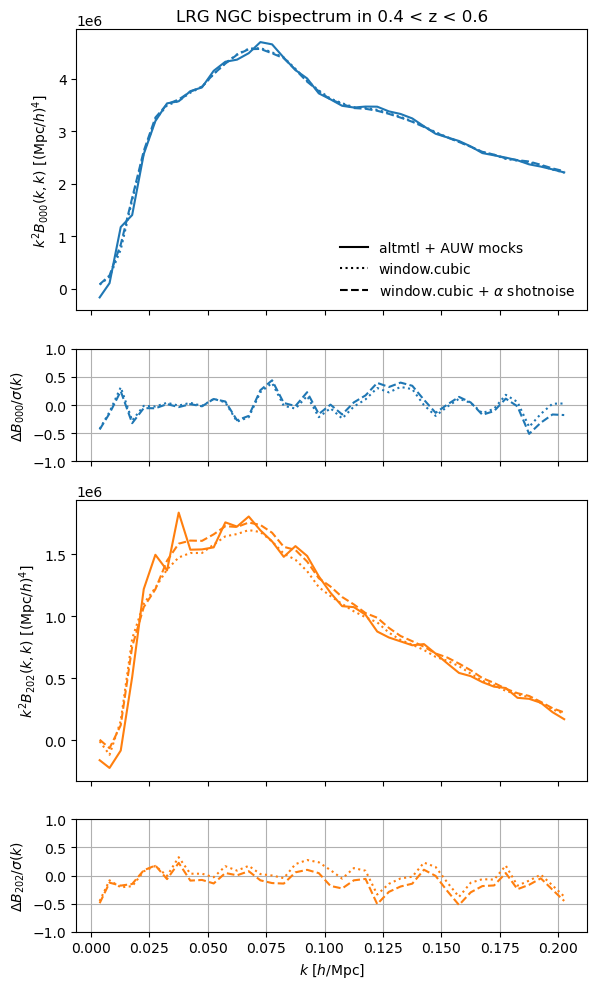

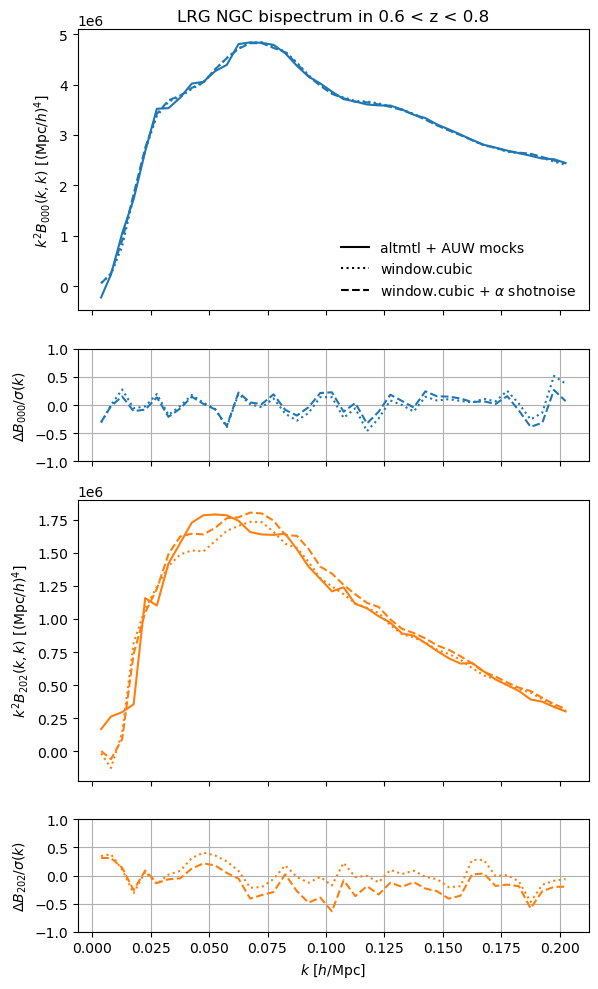

In [143]:
for tracer in ['LRG', 'ELG', 'QSO'][:1]:
    for zrange in tools.propose_fiducial('zranges', tracer)[:2]:
        for kind in ['mesh2_spectrum', 'mesh3_spectrum'][1:]:
            nmocks = 25
            region = 'NGC'
            zsnap = box_tools.get_zsnap_from_z(tracer, zrange, version='abacus-hf-v2')
            stracer = tools.get_simple_tracer(tracer)
            stats_dir = tools.base_stats_dir
            hod = {'LRG': 'base_B', 'ELG': 'base_conf_nfwexp', 'QSO': 'base'}[stracer]
            fns = [box_tools.get_box_stats_fn(stats_dir=stats_dir, project='full_shape/box_window_function_validation', kind=kind, version='abacus-hf-v2', tracer=stracer,
                                              zsnap=zsnap, cosmo='000', hod=hod, los='z', basis='sugiyama', imock=imock) for imock in range(nmocks)]
            mocks_box = [types.read(fn) for fn in fns if fn.exists()]
            mean_box = types.mean(mocks_box)

            onthefly = 'complete'
            ftracer = tools.get_full_tracer(tracer, version='abacus-hf-dr2-v2-altmtl')
            fns = [tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=kind, version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra=onthefly, imock=imock) for imock in range(nmocks)]
            mocks_cutsky = [types.read(fn) for fn in fns if fn.exists()]
            mean_cutsky = types.mean(mocks_cutsky).select(k=slice(0, None, 5 if 'mesh2' in kind else 1))

            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version='holi-v3-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.match(mean_cutsky)

            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind}', version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                    zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra=onthefly, imock=0)
            window_cutsky1 = types.read(fn).at.observable.match(mean_cutsky)

            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/cutsky_window_function_validation', kind=f'window_{kind}', version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                    zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra=f'{onthefly}_smooth_particle' if onthefly else 'smooth_particle', imock=0)
            window_cutsky2 = types.read(fn).at.observable.match(mean_cutsky)
            list_mean_box_conv, list_mean_box_conv_shotnoise = [], []
            for window_cutsky in [window_cutsky1, window_cutsky2]:
                #window_cutsky = window_cutsky.at.theory.get(ells=[(0, 0, 0), (0, 2, 2), (2, 2, 0), (1, 1, 0), (2, 2, 2)])
                mean_box_interp = []
                for label, pole in window_cutsky.theory.items():
                    pole_box = mean_box.get(ells=label['ells'])
                    if 'mesh3' in kind:
                        pole_box = pole_box.unravel()
                        from scipy import interpolate
                        mask1, mask2 = [np.any(pole_box.values('nmodes') > 0, axis=axis) for axis in [1, 0]]
                        spline = interpolate.RectBivariateSpline(pole_box.coords('k1')[mask1], pole_box.coords('k2')[mask2], pole_box.value()[np.ix_(mask1, mask2)], kx=1, ky=1, s=0)
                        pole = spline(*pole.coords('k').T, grid=False)
                    else:
                        mask = pole_box.values('nmodes') > 0
                        pole = np.interp(pole.coords('k'), pole_box.coords('k')[mask], pole_box.value()[mask])
                    mean_box_interp.append(pole)
                mean_box_interp = window_cutsky.theory.clone(value=np.concatenate(mean_box_interp))
                mean_box_conv = window_cutsky.dot(mean_box_interp, return_type=None)
                
                shotnoise = window_cutsky.theory.clone(value=0. * window_cutsky.theory.value()).value(concatenate=False)
                shotnoise[0] += next(iter(mean_cutsky)).values('shotnoise').mean()
                shotnoise = window_cutsky.dot(np.concatenate(shotnoise), return_type='nparray')[None, ...]
                precision = np.diag(1. / cov.std())
                # Solve d\chi^2 / drescale = 0, theory = rescale * shotnoise, data = mean_cutsky - mean_box_conv
                rescale = np.linalg.solve(shotnoise.dot(precision).dot(shotnoise.T), shotnoise.dot(precision).dot(mean_cutsky.value() - mean_box_conv.value()))
                mean_box_conv_shotnoise = mean_box_conv.clone(value=mean_box_conv.value() + rescale.dot(shotnoise))
                list_mean_box_conv.append(mean_box_conv)
                list_mean_box_conv_shotnoise.append(mean_box_conv_shotnoise)

            nmocks = min(len(mocks_box), len(mocks_cutsky))  # scale error bars
            if 'mesh2' in kind:
                ells = mean_cutsky.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_cutsky.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = list_mean_box_conv_shotnoise[0].get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    pole = list_mean_box_conv_shotnoise[1].get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    std = cov.at.observable.get(ell).std()
                    pole_cutsky = mean_cutsky.get(ell)
                    pole = list_mean_box_conv_shotnoise[0].get(ell)
                    ax.plot(pole.coords('k'), (pole_cutsky.value() - pole.value()) / std, color=color, linestyle=':')
                    pole = list_mean_box_conv_shotnoise[1].get(ell)
                    ax.plot(pole.coords('k'), (pole_cutsky.value() - pole.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='altmtl + AUW mocks')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            elif 'mesh3' in kind:
                ells = mean_cutsky.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    #pole = mean_box.get(tuple(sorted(ell[:2])) + ell[2:]).select(k=(0., 0.2)).unravel()
                    #ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle='-.')
                    #pole = mean_box_interp.get(ells=tuple(sorted(ell[:2])) + ell[2:]).unravel()
                    #ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle='-')
                    pole = mean_cutsky.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    pole = list_mean_box_conv_shotnoise[0].get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle=':')
                    pole = list_mean_box_conv_shotnoise[1].get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    std = cov.at.observable.get(ell).std()
                    pole_cutsky = mean_cutsky.get(ell)
                    pole = list_mean_box_conv_shotnoise[0].get(ell)
                    ax.plot(k, (pole_cutsky.value() - pole.value()) / std, color=color, linestyle=':')
                    pole = list_mean_box_conv_shotnoise[1].get(ell)
                    ax.plot(k, (pole_cutsky.value() - pole.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='altmtl + AUW mocks')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_window_auw_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            #fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()